# Detecting Types of Missing Data in Python
### MCAR vs MAR vs MNAR — a Data Scientist's Practical Reference

This notebook is built for **interview revision**, not for deep statistical theory. The goal is:
for a given dataset with missing values, know **which techniques to reach for** to figure out
what kind of missingness you're dealing with, and **what conclusion each technique lets you draw**.

**Quick recap of the three types:**

| Type | Depends on... | Example |
|---|---|---|
| **MCAR** | Nothing — pure random | Sensor randomly fails to record a value |
| **MAR** | An **observed** column | Men skip a survey question more than women |
| **MNAR** | The missing value itself, or an **unobserved** column | High earners don't report income |

**Important mindset for interviews:** There is **no single test that proves MNAR**. You can
statistically test for MCAR, and you can statistically test for MAR-type dependencies — but MNAR
is usually concluded by **elimination + domain knowledge + sensitivity analysis**, not a direct test.


## 0. Setup

In [32]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from pyampute.exploration.mcar_statistical_tests import MCARTest

np.random.seed(42)
pd.set_option('display.precision', 2)

## 1. Build a Synthetic Dataset (one example of each missingness type)

We'll deliberately engineer missingness so we **know the ground truth** — this is the best way
to build intuition, since in real datasets you never actually know the true mechanism.

- **`age`** → missing **completely at random** (a random 15% dropped, no reason at all)
- **`wellbeing_score`** → missing **at random**, dependent on the **observed** `gender` column
  (men skip it more often)
- **`income`** → missing **not at random** — high earners are less likely to report income
  (depends on the value itself, which we don't see once it's missing)


In [33]:
n = 500

age = np.random.normal(40, 12, n)
gender = np.random.choice(['M', 'F'], n)
income = 30000 + age * 800 + np.random.normal(0, 8000, n)
wellbeing_score = np.random.normal(50, 10, n)

df = pd.DataFrame({
    'age': age,
    'gender': gender,
    'income': income,
    'wellbeing_score': wellbeing_score
})

# --- MCAR: purely random missingness in 'age' ---
mcar_mask = np.random.rand(n) < 0.15
df.loc[mcar_mask, 'age'] = np.nan

# --- MAR: 'wellbeing_score' missing more often for males (explained by OBSERVED 'gender') ---
mar_mask = (df['gender'] == 'M') & (np.random.rand(n) < 0.35)
df.loc[mar_mask, 'wellbeing_score'] = np.nan

# --- MNAR: high earners less likely to report income (depends on income ITSELF) ---
mnar_prob = 1 / (1 + np.exp(-(df['income'] - 70000) / 10000))
mnar_mask = np.random.rand(n) < mnar_prob * 0.6
df.loc[mnar_mask, 'income'] = np.nan

print(df.isna().sum())
df.head()

age                 89
gender               0
income             115
wellbeing_score     86
dtype: int64


,age,gender,income,wellbeing_score
0,45.96,F,61133.71,51.22
1,38.34,F,49404.97,55.43
2,47.77,F,55764.78,50.49
3,58.28,M,81469.17,50.41
4,37.19,F,49508.69,42.98


---
## 2. Detecting MCAR

### 2.1 Visualize the missingness pattern first (always start here)

Before running any test, **look at the data**. `missingno` gives you 3 quick views:
- **Matrix** → shows *where* values are missing, row by row
- **Bar chart** → shows *how much* is missing per column
- **Heatmap** → shows whether missingness in one column tends to **co-occur** with missingness
  in another column (a strong correlation here is often the first clue something is MAR, not MCAR)


c:\Users\avanindra Bose\ML Tips\.venv\Lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


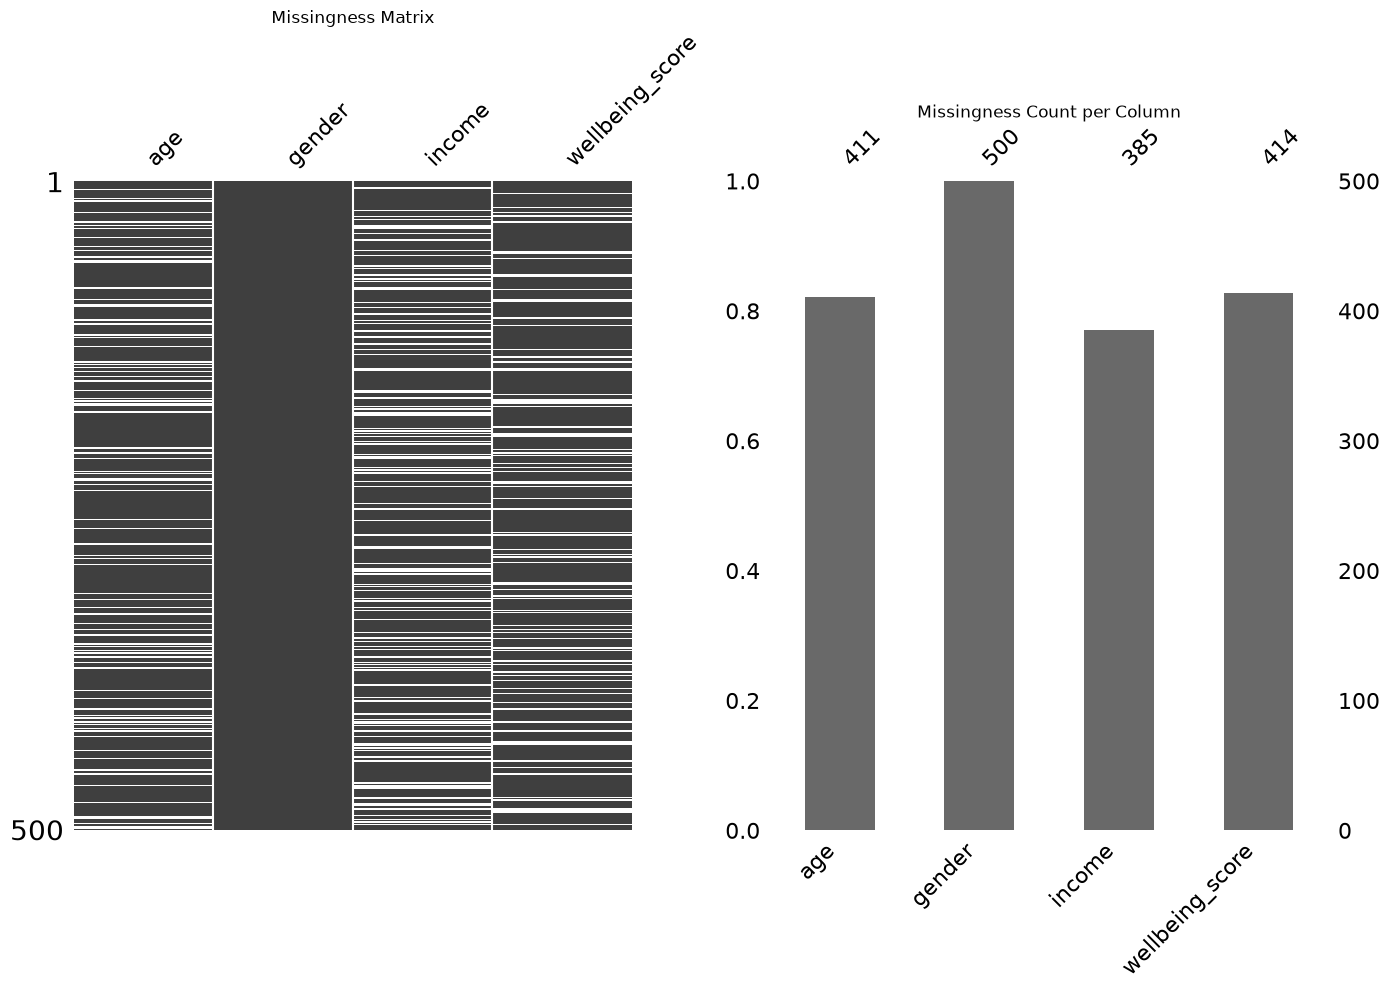

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
msno.matrix(df, ax=axes[0])
axes[0].set_title("Missingness Matrix")
msno.bar(df, ax=axes[1])
axes[1].set_title("Missingness Count per Column")
plt.tight_layout()
plt.show()

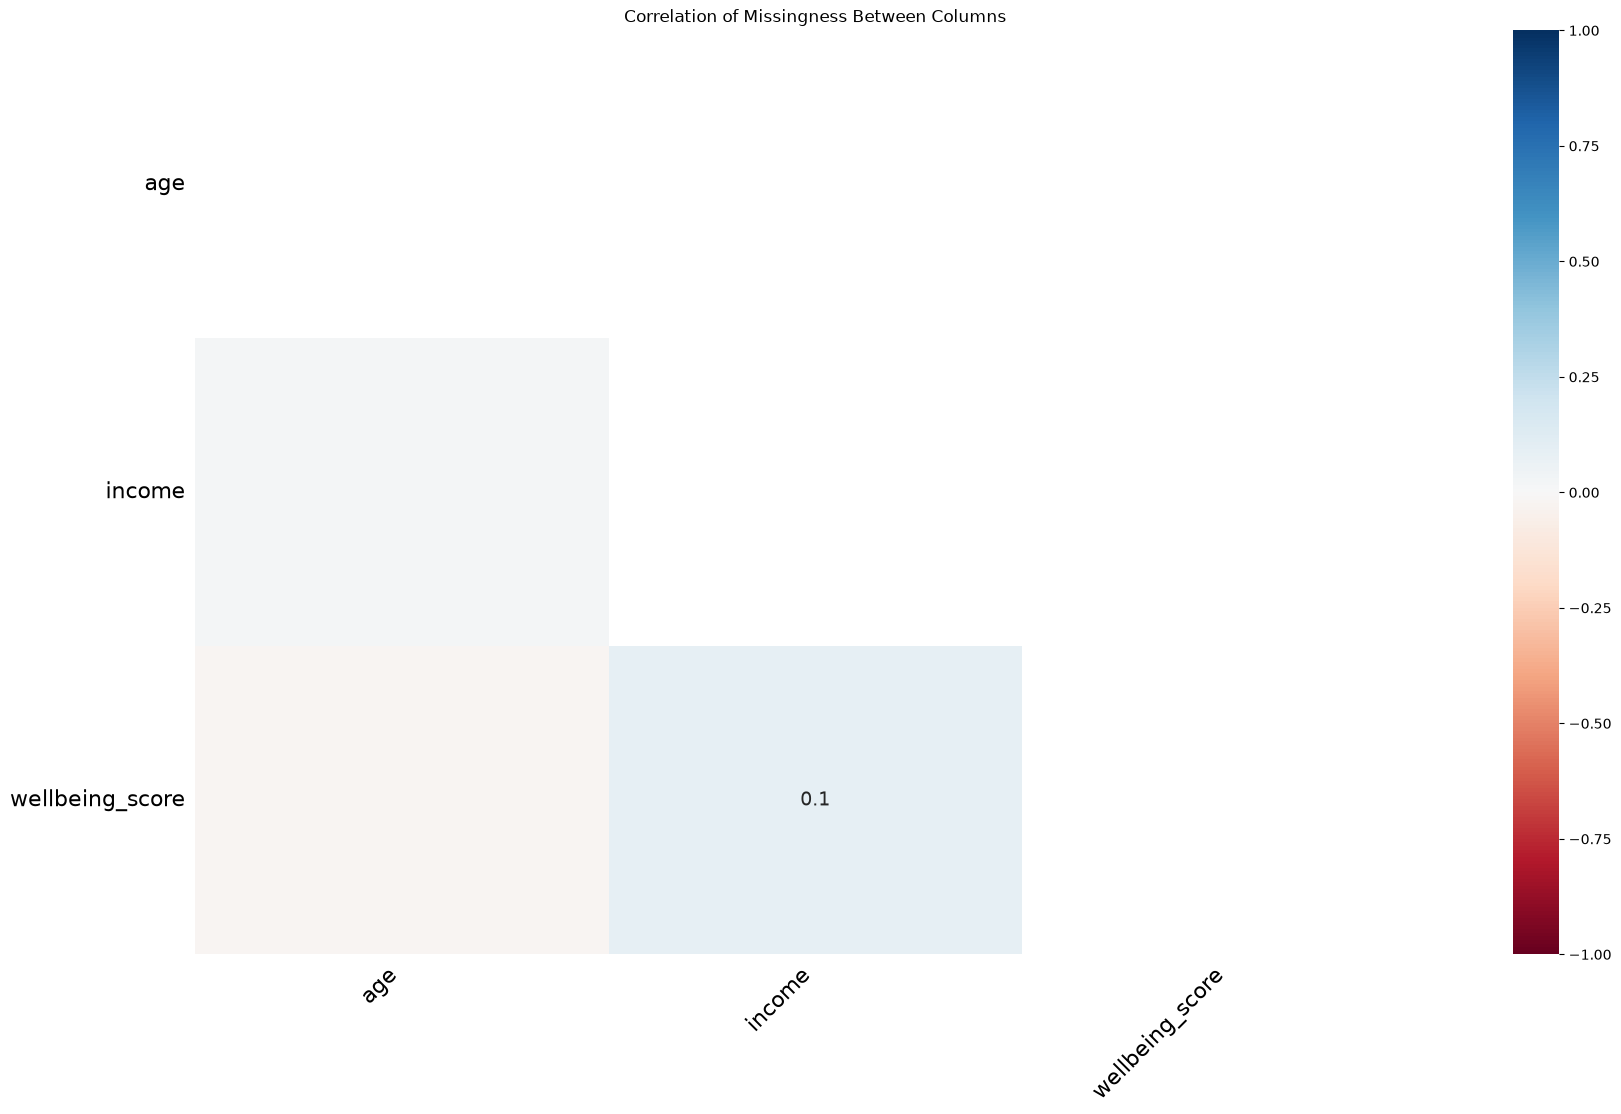

In [35]:
msno.heatmap(df)
plt.title("Correlation of Missingness Between Columns")
plt.show()

### 2.2 Little's MCAR Test

**What it tests:** H0 = data is MCAR. A low p-value (< 0.05) means you **reject MCAR** —
i.e., the missingness is *not* purely random (it's likely MAR or MNAR, but this test can't
tell you which).

**Limitation to remember for interviews:** Little's test only works well on **numeric**
columns and assumes multivariate normality. It also can't distinguish MAR from MNAR —
it's purely a yes/no gate for MCAR.


In [36]:
numeric_df = df[['age', 'income', 'wellbeing_score']]

mt = MCARTest(method="little")
p_value = mt.little_mcar_test(numeric_df)

print(f"Little's MCAR test p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0 -> NOT MCAR (likely MAR or MNAR somewhere in this data)")
else:
    print("Fail to reject H0 -> consistent with MCAR")

Little's MCAR test p-value: 0.0000
Reject H0 -> NOT MCAR (likely MAR or MNAR somewhere in this data)


**Interpreting the result above:** since we deliberately built MAR (`wellbeing_score`) and
MNAR (`income`) mechanisms into this dataset, we *expect* Little's test to reject MCAR overall.
This matches the real-world workflow: Little's test tells you "something non-random is going
on somewhere," and then you investigate column-by-column (next sections) to find out where
and what kind.


### 2.3 Visual Inspection of the suspect column

Plot a kde plot before dropping missing values from the column.

then drop the misisng values.

PLot a Kde plot again after dropping values.

__Thumb Rule__ : If there's no not much significant difference then we can say that data is MCAR.

In [37]:
dropped_df = df['age'].dropna()

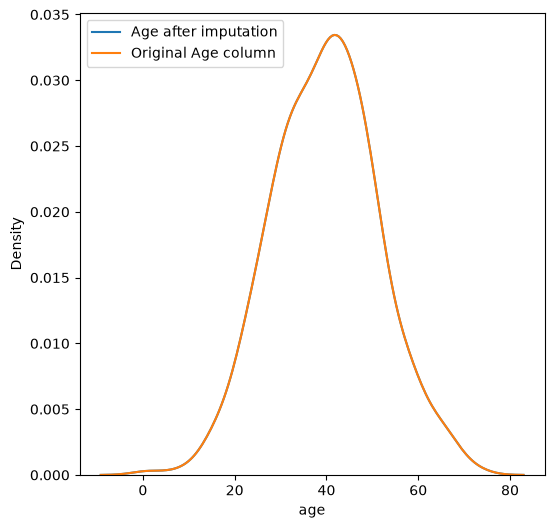

In [38]:
plt.figure(figsize=(6, 6))

sns.kdeplot(dropped_df, label='Age after imputation')
sns.kdeplot(df['age'], label='Original Age column')

plt.legend()
plt.show()

---
## 3. Detecting MAR

The core idea: **create a "missingness indicator" (0/1) for the column you're investigating,
then test whether that indicator is statistically associated with any OTHER observed column.**

If yes → that's evidence of MAR (missingness explained by an observed variable).


### 3.1 Categorical predictor → Chi-square test

Use this when checking whether missingness is associated with a **categorical** column
(like `gender`).


In [39]:
df['wellbeing_missing'] = df['wellbeing_score'].isna().astype(int)

contingency = pd.crosstab(df['gender'], df['wellbeing_missing'])
print(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square p-value: {p:.6f}")
if p < 0.05:
    print("Significant association -> supports MAR (missingness in wellbeing_score")
    print("is explained by the observed 'gender' column)")
else:
    print("No significant association found with gender")

wellbeing_missing    0   1
gender                    
F                  240   0
M                  174  86

Chi-square p-value: 0.000000
Significant association -> supports MAR (missingness in wellbeing_score
is explained by the observed 'gender' column)


### 3.2 Continuous predictor → t-test / Mann-Whitney U test

Use this when checking whether missingness is associated with a **continuous** column.
Split the continuous variable into two groups (missing vs not-missing on the target column)
and compare their means/distributions.


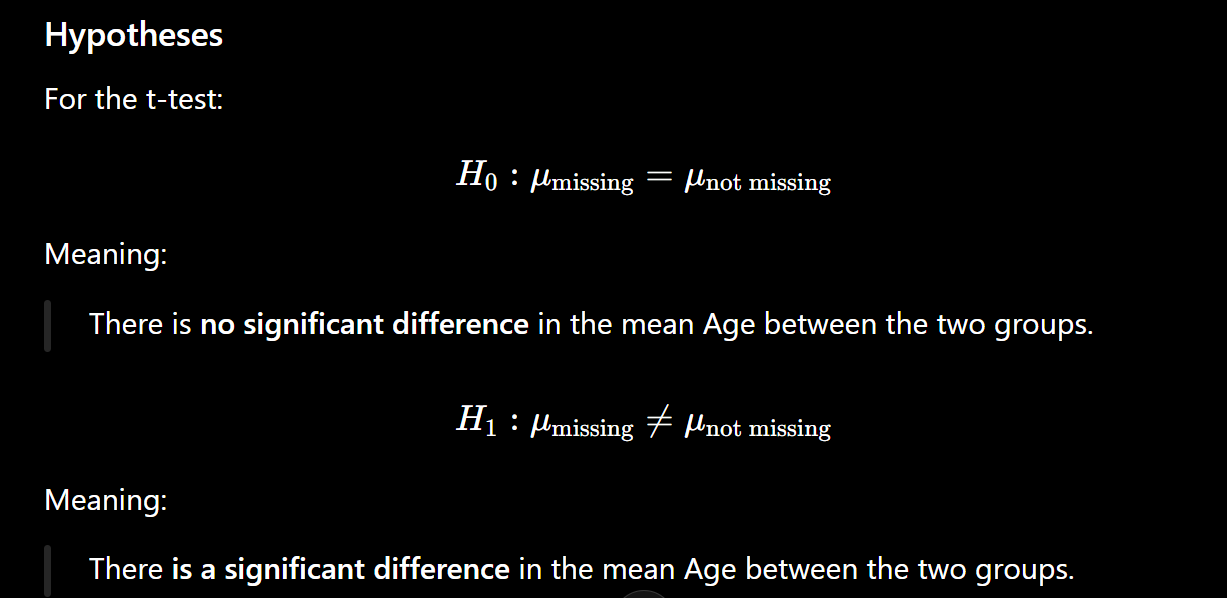

In [40]:
group_missing = df.loc[df['wellbeing_missing'] == 1, 'age'].dropna()
group_not_missing = df.loc[df['wellbeing_missing'] == 0, 'age'].dropna()

t_stat, p_val = stats.ttest_ind(group_missing, group_not_missing, equal_var=False)
print(f"T-test p-value (age vs wellbeing missingness): {p_val:.4f}")

# Mann-Whitney U is the non-parametric alternative -- safer if age isn't normally distributed
u_stat, p_val_mw = stats.mannwhitneyu(group_missing, group_not_missing)
print(f"Mann-Whitney U p-value: {p_val_mw:.4f}")

T-test p-value (age vs wellbeing missingness): 0.0351
Mann-Whitney U p-value: 0.0364


p < 0.05
      ↓
Reject H₀
      ↓
Evidence of a significant difference in Age
between missing and non-missing groups
      ↓
Age may be associated with the missingness
      ↓
This is evidence consistent with MAR

p >= 0.05
      ↓
Fail to reject H₀
      ↓
No statistically significant difference detected
      ↓
No evidence from Age that explains the missingness

### 3.3 Logistic Regression approach (handles multiple predictors at once)

Instead of testing one column at a time, fit a logistic regression predicting the missingness
indicator from **all** other observed columns simultaneously. Significant coefficients (or a
good AUC) point to which variables explain the missingness — i.e., evidence for MAR.


In [41]:
df

,age,gender,income,wellbeing_score,wellbeing_missing
0,45.96,F,61133.71,51.22,0
1,38.34,F,49404.97,55.43,0
2,47.77,F,55764.78,50.49,0
3,58.28,M,81469.17,50.41,0
4,37.19,F,49508.69,42.98,0
...,...,...,...,...,...
495,46.47,M,NaN,NaN,1
496,27.55,M,53833.75,55.14,0
497,NaN,M,71085.87,51.80,0
498,NaN,F,54595.86,53.51,0


In [42]:
X = pd.get_dummies(df[['gender']], drop_first=True)
X['income_filled'] = df['income'].fillna(df['income'].median())  # simple fill just for this diagnostic
X['age_filled'] = df['age'].fillna(df['age'].median())

y = df['wellbeing_missing']

clf = LogisticRegression()
clf.fit(X, y)

auc = roc_auc_score(y, clf.predict_proba(X)[:, 1])
print(f"AUC predicting wellbeing_score missingness from other columns: {auc:.3f}")
print("\nCoefficients:")
for col, coef in zip(X.columns, clf.coef_[0]):
    print(f"  {col}: {coef:.3f}")

print("\nRule of thumb: AUC well above 0.5 (e.g. > 0.65-0.7) means the other columns can meaningfully")
print("predict missingness -> supports MAR. AUC close to 0.5 means no observed column explains it")
print("well -> points toward MCAR or MNAR instead.")

AUC predicting wellbeing_score missingness from other columns: 0.834

Coefficients:
  gender_M: 3.454
  income_filled: -0.000
  age_filled: 0.035

Rule of thumb: AUC well above 0.5 (e.g. > 0.65-0.7) means the other columns can meaningfully
predict missingness -> supports MAR. AUC close to 0.5 means no observed column explains it
well -> points toward MCAR or MNAR instead.


---
## 4. Detecting (Suspecting) MNAR

**Key interview point:** MNAR **cannot be directly proven** from the data you have — by
definition, the reason is either the missing value itself or a variable you never measured.
So the workflow is different from MCAR/MAR: it's **detection by elimination + domain reasoning**,
not a single clean test.

### 4.1 The elimination logic

1. Run Little's test → if it rejects MCAR, something non-random is happening.
2. Test the missingness indicator against **every observed column** you have (Section 3 methods).
3. **If no observed column explains the missingness *as strongly or as clearly* as a real MAR
   case does** — lower AUC, no single dominant predictor, weaker/less clean associations —
   the mechanism is probably not MAR. Combined with ruling out MCAR (via Little's test) and
   domain knowledge about *why* the value might be self-censored, this points toward **MNAR**
   by elimination, not by a single decisive test.

**Realistic caveat:** in practice, this is rarely a clean "AUC near 0.5" story — unrelated-looking
columns can still weakly correlate with a sensitive variable (as you'll see below), so look at
the *relative* strength and clarity of evidence, not just a hard threshold.


In [43]:
# Apply the same logistic regression check to 'income' missingness
df['income_missing'] = df['income'].isna().astype(int)

X2 = pd.get_dummies(df[['gender']], drop_first=True)
X2['age_filled'] = df['age'].fillna(df['age'].median())
X2['wellbeing_filled'] = df['wellbeing_score'].fillna(df['wellbeing_score'].median())

y2 = df['income_missing']
clf2 = LogisticRegression()
clf2.fit(X2, y2)
auc2 = roc_auc_score(y2, clf2.predict_proba(X2)[:, 1])

print(f"AUC predicting income missingness from OTHER observed columns: {auc2:.3f}")
print("\nNotice this AUC (~0.68) is moderate, not close to 0.5 -- and NOT as low as you might")
print("expect for 'pure' MNAR. Why? Because 'age' happens to correlate with 'income' in this")
print("dataset (income was generated partly from age), so age indirectly leaks some signal")
print("about income even though it doesn't directly cause the missingness.")
print("")
print("This is a realistic and important nuance: in real data, MNAR mechanisms rarely give a")
print("clean 'AUC near 0.5' signal, because unrelated-looking columns can still be correlated")
print("with the sensitive variable. The key comparison that matters is RELATIVE:")
print(f"  - MAR column (wellbeing_score) AUC = 0.834  <- clearly explained by 'gender'")
print(f"  - Suspected MNAR column (income) AUC = {auc2:.3f}  <- lower, and no single predictor")
print("    dominates the coefficients the way 'gender' did for wellbeing_score.")
print("Combined with domain knowledge ('high earners under-report income') and the visual")
print("distribution check below, this pattern points toward MNAR rather than a strong MAR link.")

AUC predicting income missingness from OTHER observed columns: 0.678

Notice this AUC (~0.68) is moderate, not close to 0.5 -- and NOT as low as you might
expect for 'pure' MNAR. Why? Because 'age' happens to correlate with 'income' in this
dataset (income was generated partly from age), so age indirectly leaks some signal
about income even though it doesn't directly cause the missingness.

This is a realistic and important nuance: in real data, MNAR mechanisms rarely give a
clean 'AUC near 0.5' signal, because unrelated-looking columns can still be correlated
with the sensitive variable. The key comparison that matters is RELATIVE:
  - MAR column (wellbeing_score) AUC = 0.834  <- clearly explained by 'gender'
  - Suspected MNAR column (income) AUC = 0.678  <- lower, and no single predictor
    dominates the coefficients the way 'gender' did for wellbeing_score.
Combined with domain knowledge ('high earners under-report income') and the visual
distribution check below, this pattern poi

### 4.2 Look for a suspicious pattern in the observed (non-missing) values

A classic MNAR fingerprint: if you plot the **observed** values of the suspect column, and
the distribution looks artificially cut off (e.g., missing values seem to cluster where
you'd expect very high or very low values), that's a visual clue the missingness depends on
the value itself.


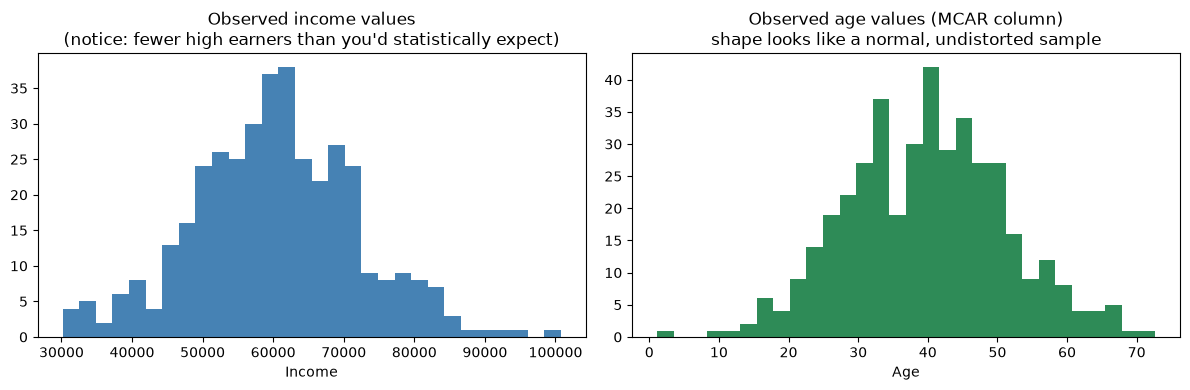

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df['income'].dropna(), bins=30, color='steelblue')
ax[0].set_title("Observed income values\n(notice: fewer high earners than you'd statistically expect)")
ax[0].set_xlabel("Income")

ax[1].hist(df['age'].dropna(), bins=30, color='seagreen')
ax[1].set_title("Observed age values (MCAR column)\nshape looks like a normal, undistorted sample")
ax[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

### 4.3 Sensitivity Analysis (the standard way to *handle*, not detect, suspected MNAR)

Since you can't know the truth, you test **multiple plausible assumptions** about the missing
values and see how much your conclusions change. If your conclusion holds up across all
assumptions, you can be more confident despite the missingness. If it swings wildly, you must
flag that your results are sensitive to the MNAR mechanism.


In [45]:
observed_mean = df['income'].dropna().mean()
print(f"Mean income using only observed (non-missing) data: {observed_mean:,.0f}")
print("(This is likely an UNDERESTIMATE, since high earners are more likely to be missing)\n")

# Try a few plausible assumptions about how much higher the missing incomes really are
for uplift_pct in [0, 10, 20, 30]:
    assumed_missing_value = observed_mean * (1 + uplift_pct / 100)
    n_missing = df['income'].isna().sum()
    n_total = len(df)

    adjusted_total = df['income'].dropna().sum() + assumed_missing_value * n_missing
    adjusted_mean = adjusted_total / n_total

    print(f"Assumption: missing incomes are {uplift_pct}% higher on average "
          f"-> adjusted overall mean = {adjusted_mean:,.0f}")

print("\nIf the adjusted mean changes a lot across these assumptions, the analysis is")
print("'sensitive' to the MNAR mechanism -- report this range rather than a single number.")

Mean income using only observed (non-missing) data: 60,367
(This is likely an UNDERESTIMATE, since high earners are more likely to be missing)

Assumption: missing incomes are 0% higher on average -> adjusted overall mean = 60,367
Assumption: missing incomes are 10% higher on average -> adjusted overall mean = 61,755
Assumption: missing incomes are 20% higher on average -> adjusted overall mean = 63,144
Assumption: missing incomes are 30% higher on average -> adjusted overall mean = 64,532

If the adjusted mean changes a lot across these assumptions, the analysis is
'sensitive' to the MNAR mechanism -- report this range rather than a single number.


---
## 5. Cheat Sheet — Decision Workflow for Interviews

```
1. Visualize missingness first
   -> msno.matrix(), msno.bar(), msno.heatmap()

2. Run Little's MCAR test on numeric columns
   -> p >= 0.05: consistent with MCAR, likely safe to proceed with simple methods
   -> p < 0.05: NOT MCAR -> go to step 3

3. For each column with missing values, test its missingness indicator against
   every OTHER observed column:
   -> Categorical predictor -> chi-square test (pd.crosstab + stats.chi2_contingency)
   -> Continuous predictor  -> t-test / Mann-Whitney U (stats.ttest_ind / mannwhitneyu)
   -> Multiple predictors   -> Logistic regression + AUC
   -> Significant relationship found -> MAR (can be handled with multiple imputation
      using the related columns)

4. If NO observed column explains the missingness well:
   -> Rule of thumb: it's not MCAR (already rejected) and not explained by anything
      you can observe -> suspect MNAR
   -> Confirm with domain knowledge + look for distributional red flags
      (truncation, ceiling/floor effects, suspiciously "clean" cutoffs)

5. If MNAR is suspected:
   -> You cannot fully fix it with standard imputation
   -> Run a SENSITIVITY ANALYSIS: test multiple plausible assumptions about the
      missing values, and report how much your conclusions change
```

### One-line recall for each

- **MCAR** → Little's test, p >= 0.05 → safe to ignore/impute simply.
- **MAR** → missingness indicator + chi2/t-test/logistic regression against other
  columns → significant → use multiple imputation.
- **MNAR** → nothing observed explains it + domain knowledge says otherwise →
  can't test directly → use sensitivity analysis.
